<a href="https://colab.research.google.com/github/Mohamed-Hesham-Latif/ML-55-25005/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [1]:
import pandas as pd
import numpy as np
import zipfile
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
urllib.request.urlretrieve(url, "bank.zip")

# Extract
with zipfile.ZipFile("bank.zip", "r") as zip_ref:
    zip_ref.extractall("bank_data")

# Load full dataset
df = pd.read_csv(
    "bank_data/bank-additional/bank-additional-full.csv",
    sep=";"
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
target_col = "y"

numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

# Remove target column
categorical_features.remove(target_col)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [3]:
numeric_summary = df[numeric_features].describe().T
numeric_summary["skewness"] = df[numeric_features].skew()

display(numeric_summary)


,count,mean,std,min,25%,50%,75%,max,skewness
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000,0.784697
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000,3.263141
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000,4.762507
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000,-4.922190
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000,3.832042
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400,-0.724096
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767,-0.230888
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900,0.303180
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045,-0.709188
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100,-1.044262


In [4]:
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts())



Value counts for job:


,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060



Value counts for marital:


,count
marital,
married,24928
single,11568
divorced,4612
unknown,80



Value counts for education:


...

,count
month,
may,13769
jul,7174
aug,6178
jun,5318
nov,4101
apr,2632
oct,718
sep,570
mar,546



Value counts for day_of_week:


,count
day_of_week,
thu,8623
mon,8514
wed,8134
tue,8090
fri,7827



Value counts for poutcome:


,count
poutcome,
nonexistent,35563
failure,4252
success,1373


In [5]:
# Check true missing values
print("Missing values per column:")
display(df.isna().sum())

# Check 'unknown' values in categorical features
unknown_counts = {
    col: (df[col] == "unknown").sum()
    for col in categorical_features
}

unknown_df = pd.DataFrame.from_dict(
    unknown_counts, orient="index", columns=["unknown_count"]
)

display(unknown_df.sort_values("unknown_count", ascending=False))


Missing values per column:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


,unknown_count
default,8597
education,1731
housing,990
loan,990
job,330
marital,80
contact,0
month,0
day_of_week,0
poutcome,0


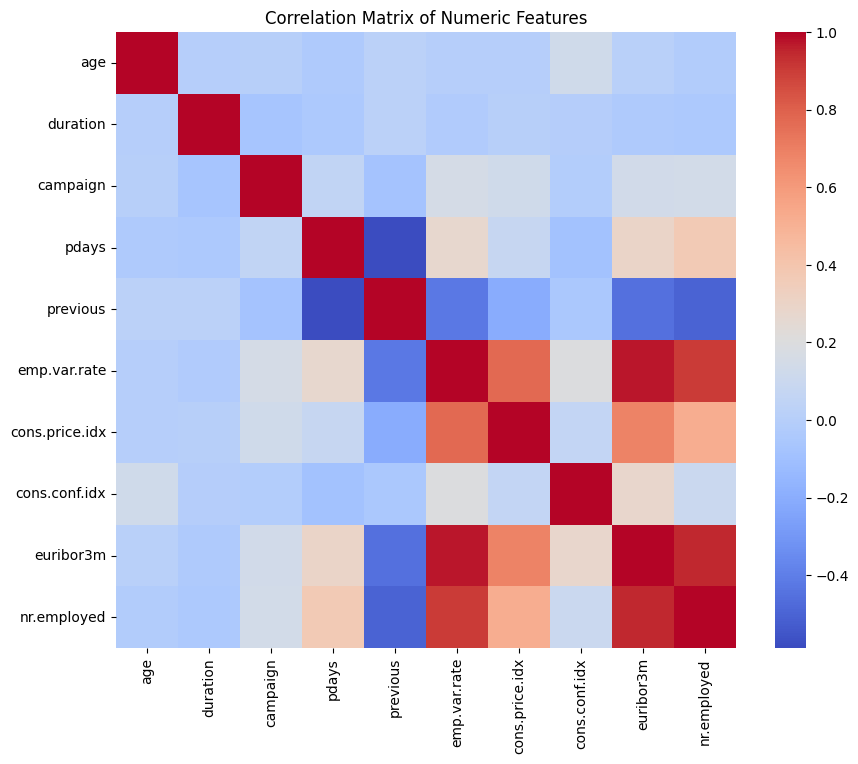

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numeric_features].corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Matrix of Numeric Features")
plt.show()



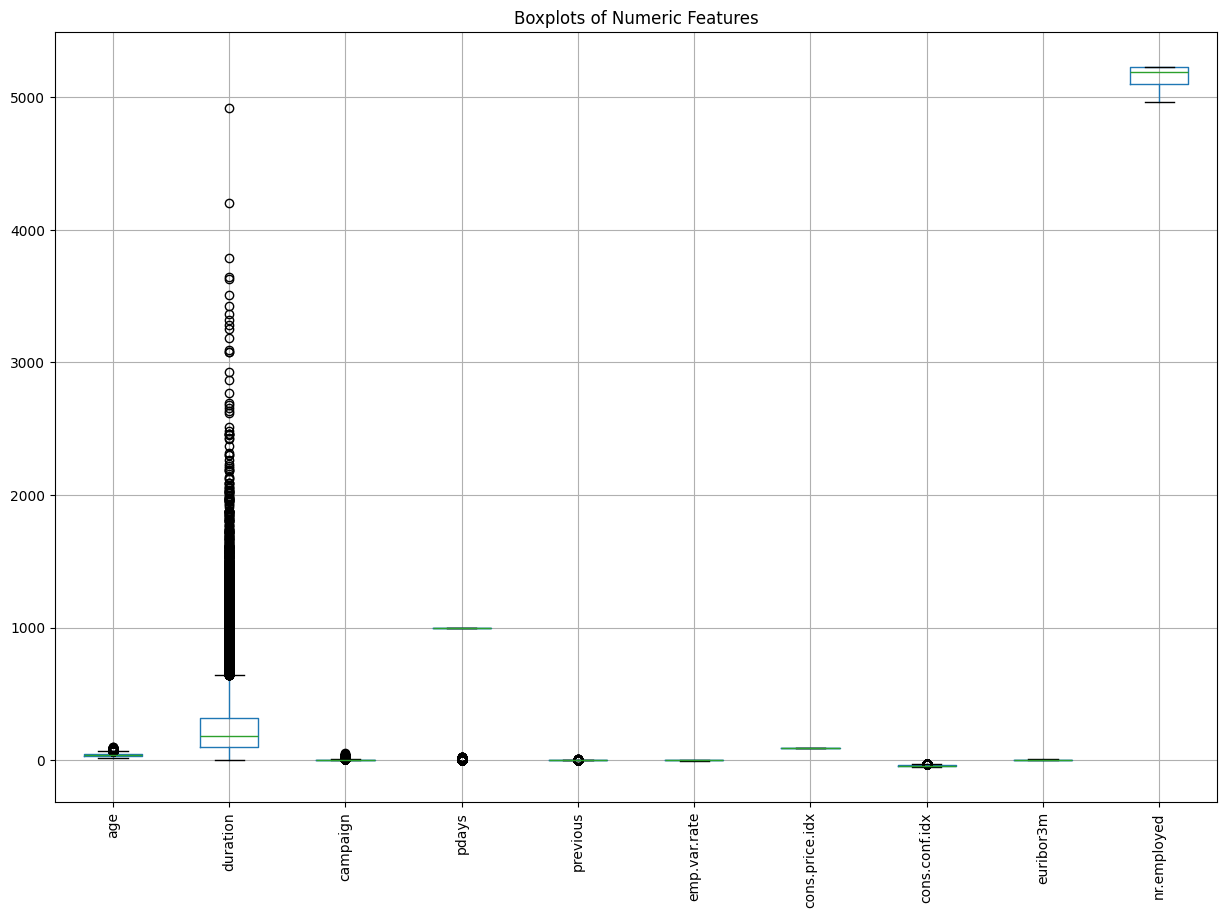

In [7]:
plt.figure(figsize=(15, 10))
df[numeric_features].boxplot(rot=90)
plt.title("Boxplots of Numeric Features")
plt.grid(True)
plt.show()


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [8]:
# -------------------------
# 1. Drop target column
# -------------------------

X = df.drop(columns=["y"])

print("Shape after dropping target:", X.shape)


Shape after dropping target: (41188, 20)


In [9]:
import numpy as np

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)


Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [10]:
# -------------------------
# 2. Encode categorical features
# -------------------------

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False   # keep all categories for clustering
)

print("Shape after encoding:", X_encoded.shape)


Shape after encoding: (41188, 63)


In [11]:
from sklearn.preprocessing import StandardScaler

# -------------------------
# 3. Scale features
# -------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns
)

display(X_scaled.head())


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.533034,0.010471,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,-0.133197,-0.118462,-0.484371,1.959,-0.514581,-0.494394,-0.496067,-0.33929,0.397706,-0.1857
1,1.628993,-0.421501,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,-0.133197,-0.118462,-0.484371,1.959,-0.514581,-0.494394,-0.496067,-0.33929,0.397706,-0.1857
2,-0.290186,-0.124520,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,-0.133197,-0.118462,-0.484371,1.959,-0.514581,-0.494394,-0.496067,-0.33929,0.397706,-0.1857
3,-0.002309,-0.413787,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,-0.133197,-0.118462,-0.484371,1.959,-0.514581,-0.494394,-0.496067,-0.33929,0.397706,-0.1857
4,1.533034,0.187888,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,...,-0.133197,-0.118462,-0.484371,1.959,-0.514581,-0.494394,-0.496067,-0.33929,0.397706,-0.1857


In [12]:
# -------------------------
# 4. Final checks
# -------------------------

print("Any missing values?", X_scaled.isna().sum().sum())
print("All numeric?", X_scaled.dtypes.unique())
print("Final dataset shape:", X_scaled.shape)


Any missing values? 0
All numeric? [dtype('float64')]
Final dataset shape: (41188, 63)


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [13]:
# =========================
# Task 1 — Apply K-Means Clustering
# (assumes you already created X_scaled from Data Preparation)
# =========================

from sklearn.cluster import KMeans
import pandas as pd

# 1) Decide an initial K
# We'll start with K=3 as a reasonable baseline (common starting point in segmentation),
# and later you will pick the best K using Elbow + Silhouette.
K = 3

# 2) Fit K-Means and 3) assign each point to a cluster
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to your original dataframe for interpretation later
df_with_clusters = df.copy()
df_with_clusters["cluster"] = cluster_labels

print("K-Means fitted with K =", K)
print("Centroids shape:", kmeans.cluster_centers_.shape)

# Quick checks
print("\nCluster counts:")
print(df_with_clusters["cluster"].value_counts().sort_index())

display(df_with_clusters.head())


K-Means fitted with K = 3
Centroids shape: (3, 63)

Cluster counts:
cluster
0    13517
1    13507
2    14164
Name: count, dtype: int64


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,cluster
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

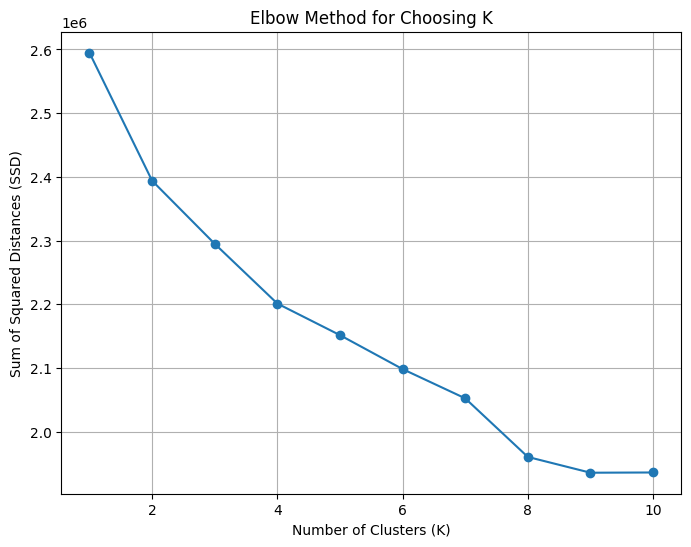

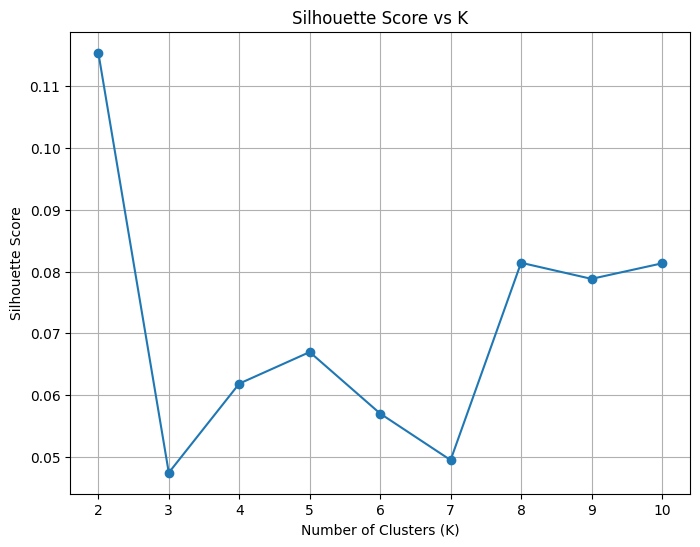

K=2: Silhouette Score=0.1154
K=3: Silhouette Score=0.0474
K=4: Silhouette Score=0.0618
K=5: Silhouette Score=0.0670
K=6: Silhouette Score=0.0570
K=7: Silhouette Score=0.0495
K=8: Silhouette Score=0.0814
K=9: Silhouette Score=0.0788
K=10: Silhouette Score=0.0813


In [14]:
# =========================
# Task 1 — Choosing the Convenient K
# 1) Elbow Method (SSD vs K)
# 2) Identify elbow point
# 3) Silhouette scores to validate K
# =========================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -------------------------
# 1) Elbow Method
# -------------------------

ssd = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    ssd.append(km.inertia_)  # Sum of Squared Distances (SSD)

# Plot SSD vs K
plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method for Choosing K")
plt.grid(True)
plt.show()

# -------------------------
# 2) Silhouette Scores
# -------------------------

silhouette_scores = []
K_sil = range(2, 11)  # silhouette requires at least 2 clusters

for k in K_sil:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Score vs K
plt.figure(figsize=(8, 6))
plt.plot(K_sil, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()

# Print scores for reference
for k, score in zip(K_sil, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")


An initial value of K = 3 was used only as a baseline.
The Elbow Method indicates that SSD reduction slows around K = 7–8, and silhouette scores are higher for K = 8 compared to smaller values.
Therefore, K = 8 was selected as the final number of clusters.
